In [50]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    classification_report
)

In [36]:
df = pd.read_csv("database.csv", low_memory=False)
df.head()

,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source
0,1,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1,Murder or Manslaughter,...,Unknown,Male,15,Native American/Alaska Native,Unknown,Acquaintance,Blunt Object,0,0,FBI
1,2,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
2,3,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,0,FBI
3,4,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
4,5,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,1,FBI


In [31]:
df.shape

(638454, 24)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638454 entries, 0 to 638453
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Record ID              638454 non-null  int64 
 1   Agency Code            638454 non-null  object
 2   Agency Name            638454 non-null  object
 3   Agency Type            638454 non-null  object
 4   City                   638454 non-null  object
 5   State                  638454 non-null  object
 6   Year                   638454 non-null  int64 
 7   Month                  638454 non-null  object
 8   Incident               638454 non-null  int64 
 9   Crime Type             638454 non-null  object
 10  Crime Solved           638454 non-null  object
 11  Victim Sex             638454 non-null  object
 12  Victim Age             638454 non-null  int64 
 13  Victim Race            638454 non-null  object
 14  Victim Ethnicity       638454 non-null  object
 15  

In [37]:
selected_features = [
    "Victim Sex",
    "Victim Age",
    "Victim Race",
    "Weapon",
    "Relationship",
    "Month",
    "Year",
    "Victim Count"
]

df = df[selected_features + ["Crime Solved"]]
df.head()


,Victim Sex,Victim Age,Victim Race,Weapon,Relationship,Month,Year,Victim Count,Crime Solved
0,Male,14,Native American/Alaska Native,Blunt Object,Acquaintance,January,1980,0,Yes
1,Male,43,White,Strangulation,Acquaintance,March,1980,0,Yes
2,Female,30,Native American/Alaska Native,Unknown,Unknown,March,1980,0,No
3,Male,43,White,Strangulation,Acquaintance,April,1980,0,Yes
4,Female,30,Native American/Alaska Native,Unknown,Unknown,April,1980,0,No


In [38]:
df.replace("Unknown", np.nan, inplace=True)

df["Victim Age"] = pd.to_numeric(df["Victim Age"], errors="coerce")
df["Victim Age"].fillna(df["Victim Age"].median(), inplace=True)

df.fillna("Unknown", inplace=True)

df.isnull().sum()


C:\Users\Moazzam Sharif\AppData\Local\Temp\ipykernel_22416\113902403.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Victim Age"].fillna(df["Victim Age"].median(), inplace=True)


Victim Sex      0
Victim Age      0
Victim Race     0
Weapon          0
Relationship    0
Month           0
Year            0
Victim Count    0
Crime Solved    0
dtype: int64

In [39]:
df["Crime Solved"] = df["Crime Solved"].map({"Yes": 1, "No": 0})
df["Crime Solved"].value_counts()

Crime Solved
1    448172
0    190282
Name: count, dtype: int64

In [40]:
X = df.drop("Crime Solved", axis=1)
y = df["Crime Solved"]

X = pd.get_dummies(X, drop_first=True)
X.head()


,Victim Age,Year,Victim Count,Victim Sex_Male,Victim Sex_Unknown,Victim Race_Black,Victim Race_Native American/Alaska Native,Victim Race_Unknown,Victim Race_White,Weapon_Drowning,...,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September
0,14,1980,0,True,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1,43,1980,0,True,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
2,30,1980,0,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,43,1980,0,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,30,1980,0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((446917, 62), (191537, 62))

In [42]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [43]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]


In [44]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]


In [45]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Logistic Regression Confusion Matrix:\n", cm_lr)
print("\nRandom Forest Confusion Matrix:\n", cm_rf)


Logistic Regression Confusion Matrix:
 [[ 51703   5382]
 [ 26619 107833]]

Random Forest Confusion Matrix:
 [[ 40946  16139]
 [ 20247 114205]]


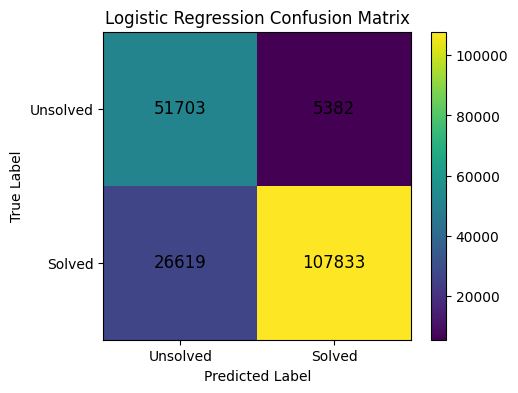

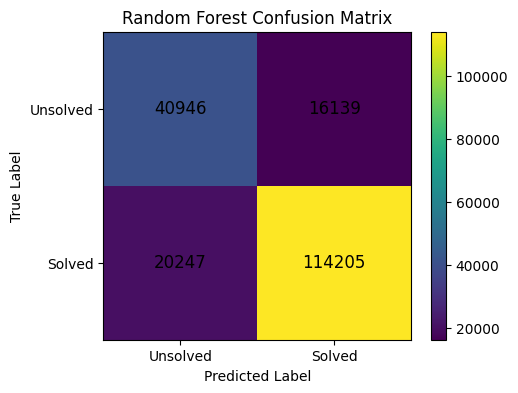

In [51]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks([0,1], ["Unsolved", "Solved"])
    plt.yticks([0,1], ["Unsolved", "Solved"])
    
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)
    
    plt.show()

plot_confusion_matrix(cm_lr, "Logistic Regression Confusion Matrix")
plot_confusion_matrix(cm_rf, "Random Forest Confusion Matrix")


In [46]:
def evaluate_model(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Error Rate:", 1 - accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

print("Logistic Regression Metrics")
evaluate_model(y_test, y_pred_lr)

print("\nRandom Forest Metrics")
evaluate_model(y_test, y_pred_rf)


Logistic Regression Metrics
Accuracy: 0.8329252311563823
Error Rate: 0.16707476884361772
Precision: 0.9524621295764696
Recall: 0.8020185642459763
F1 Score: 0.8707902142796577

Random Forest Metrics
Accuracy: 0.8100314821679362
Error Rate: 0.1899685178320638
Precision: 0.8761814889829989
Recall: 0.849410942194984
F1 Score: 0.862588558739558


In [47]:
print("Logistic Regression Report")
print(classification_report(y_test, y_pred_lr))

print("Random Forest Report")
print(classification_report(y_test, y_pred_rf))


Logistic Regression Report
              precision    recall  f1-score   support

           0       0.66      0.91      0.76     57085
           1       0.95      0.80      0.87    134452

    accuracy                           0.83    191537
   macro avg       0.81      0.85      0.82    191537
weighted avg       0.87      0.83      0.84    191537

Random Forest Report
              precision    recall  f1-score   support

           0       0.67      0.72      0.69     57085
           1       0.88      0.85      0.86    134452

    accuracy                           0.81    191537
   macro avg       0.77      0.78      0.78    191537
weighted avg       0.81      0.81      0.81    191537



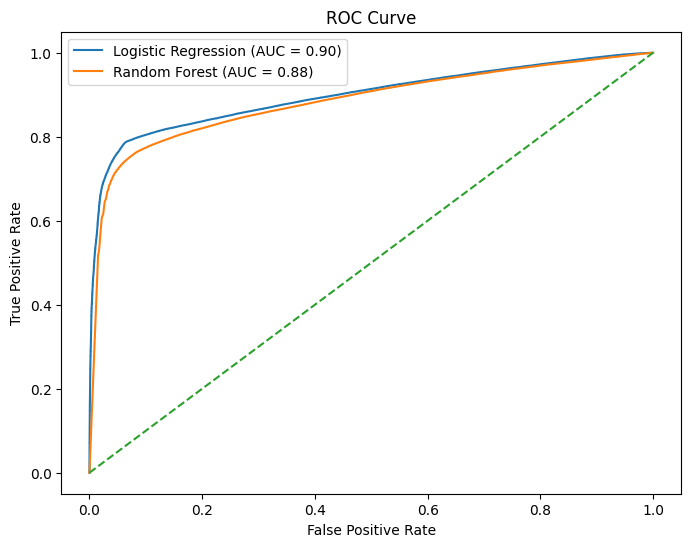

In [48]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [54]:
print(f"Logistic Regression AUC: {auc_lr:.3f}")
print(f"Random Forest AUC: {auc_rf:.3f}")


Logistic Regression AUC: 0.897
Random Forest AUC: 0.884
